In [21]:
# Importação das bibliotecas necessárias

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from modulos import exibir_resultado, avaliar_modelo, exibir_relatorio_de_classificacao, preparar_iris, exibir_melhor_resultado_do_knn, atualizar_melhor_desempenho_k, treinar_k, gerar_grafico_da_arvore_de_decisao, exibir_grafico_comparativo


In [22]:
# Importação e exploração dos dados
iris = load_iris()
X, y, feature_names, target_names = preparar_iris(iris)

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)


In [23]:
# Limitando a profundidade para evitar overfit e gerar regras legíveis
clf = DecisionTreeClassifier(max_depth=3, random_state=13)
clf.fit(X_train, y_train)

# Predição
y_pred_arvore_de_decisao = clf.predict(X_test)

# Avaliação das métricas usando Árvore de Decisão com Iris
(acuracia_arvore_decisao, precisao_arvore_decisao,
revocacao_arvore_decisao, f1_arvore_decisao) = avaliar_modelo(y_test, y_pred_arvore_de_decisao)


In [24]:
# Exibição dos resultados das métricas usando Árvore de Decisão com Iris
exibir_resultado(
    acuracia_arvore_decisao, precisao_arvore_decisao,
    revocacao_arvore_decisao, f1_arvore_decisao,
    "ÁRVORE DE DECISÃO"
    )


MÉTRICAS DE AVALIAÇÃO - ÁRVORE DE DECISÃO
Acurácia:  0.9556
Precisão:  0.9608
Revocação: 0.9556
F1-Score:  0.9554




In [25]:
# Exibição das Regras Geradas (Exigência do Relatório)
print("\nREGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):")
regras_texto = export_text(clf, feature_names=feature_names)
print(regras_texto)
print("=" * 50)



REGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):
|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



In [26]:
# Exibição do relatório de classificação da Árvore de Decisão com Iris
exibir_relatorio_de_classificacao(y_test, y_pred_arvore_de_decisao, iris)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.87      0.93        15
   virginica       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



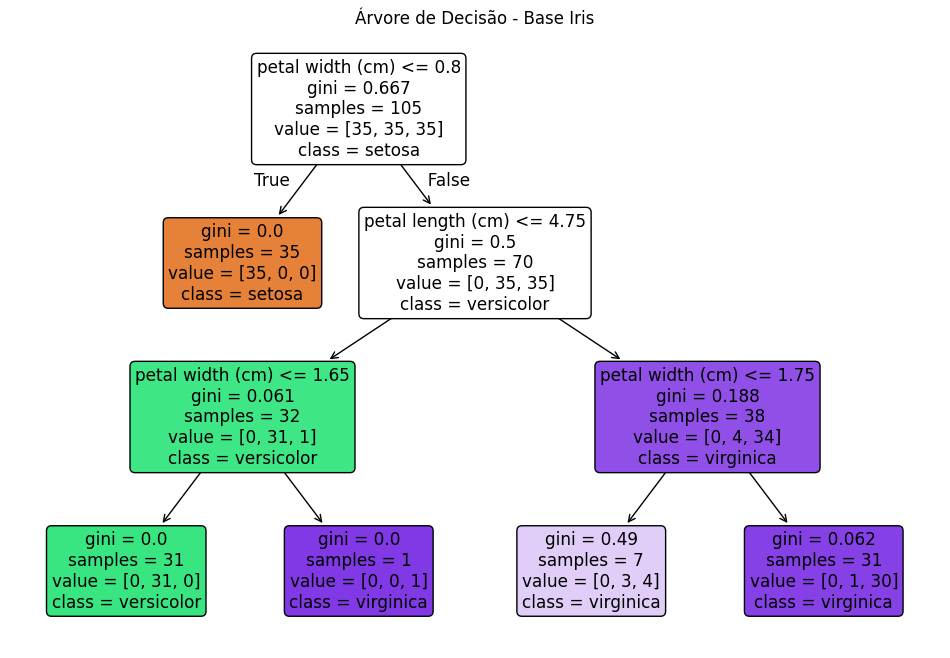

In [27]:
# Representação Gráfica da Árvore
gerar_grafico_da_arvore_de_decisao(clf, feature_names, target_names, 'Iris')

In [28]:
# Aplicação do algoritmo Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predição
y_pred_gnb = gnb.predict(X_test)

# Avaliação das métricas usando Naive Bayes com Iris
(acuracia_gaussian, precisao_gaussian,
revocacao_gaussian, f1_gaussian) = avaliar_modelo(y_test, y_pred_gnb)


In [29]:
# Exibição dos resultados das métricas avaliadas usando Naive Bayes com Iris
exibir_resultado(
    acuracia_gaussian, precisao_gaussian,
    revocacao_gaussian, f1_gaussian,
    "NAIVE BAYES"
)


MÉTRICAS DE AVALIAÇÃO - NAIVE BAYES
Acurácia:  0.9556
Precisão:  0.9608
Revocação: 0.9556
F1-Score:  0.9554




In [30]:
# Exibição do relatório de classificação do Naive Bayes com Iris
exibir_relatorio_de_classificacao(y_test, y_pred_gnb, iris)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.87      0.93        15
   virginica       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [31]:
#Estabelecendo as variáveis que serão usadas no loop do KNN

valores_k = [1, 3, 5, 7, 9, 11]
resultados_acuracia = []
melhor_k = 1
melhor_f1 = 0


In [32]:
for k in valores_k:
    # Treinando e avalianndo o modelo de acordo com o K atual
    acuracia_knn, precisao_knn, revocacao_knn, f1_knn = treinar_k(
        k, resultados_acuracia, X_train, y_train, X_test, y_test
    )

    # Exibindo o resultado do K atual
    exibir_resultado(
        acuracia_knn, precisao_knn, revocacao_knn, f1_knn,
        f"KNN (K = {k})"
    )

    # Atualizando qual é o melhor modelo baseado no F1-Score
    melhor_f1, melhor_k = atualizar_melhor_desempenho_k(f1_knn, k, melhor_f1, melhor_k)

exibir_melhor_resultado_do_knn(melhor_k, melhor_f1)


MÉTRICAS DE AVALIAÇÃO - KNN (K = 1)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 3)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 5)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 7)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778




MÉTRICAS DE AVALIAÇÃO - KNN (K = 9)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 11)
Acurácia:  1.0000
Precisão:  1.0000
Revocação: 1.0000
F1-Score:  1.0000


CONCLUSÃO: O melhor desempenho foi com K = 11 (F1-Score: 1.0000)


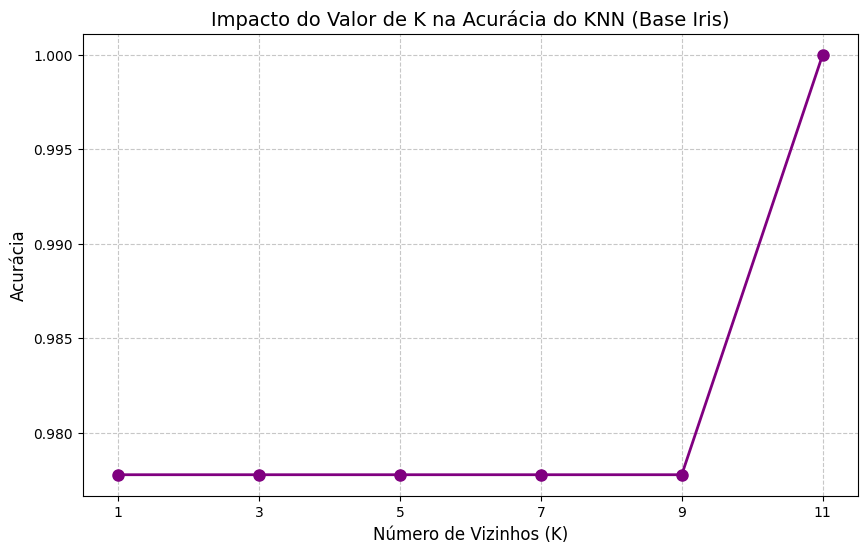

In [33]:
# Representação gráfica dos valores de K usados no KNN
exibir_grafico_comparativo(valores_k, resultados_acuracia, "Iris")
